<a href="https://colab.research.google.com/github/api-sage/systems_stochastic_processes/blob/main/jezero_crater_clustering/pafolabi_HomeWorkII.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 18-751 Homework 2, Question 5: Clustering in Jezero Crater

**Applied Stochastic Processes, Fall 2026**

Fill in every cell marked `YOUR CODE HERE`. Cells marked **PROVIDED FOR YOU** are complete already: read them, run them, but do not modify them.

The model has four components: three Gaussians for the rock types (labels 0, 1, 2)
and one uniform "garbage" component for the ChemCam misfires (label 3).

Name: ______________________   Andrew ID: ______________________

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# Reproducibility. Do not change this.
np.random.seed(2026)

plt.rcParams.update({"figure.dpi": 110, "font.size": 9,
                     "axes.grid": True, "grid.alpha": 0.25})

## Part 1, Task 1: Generate and inspect the data (provided)

In [2]:
# =====================================================================
# PROVIDED FOR YOU. DO NOT MODIFY THIS CELL.
# =====================================================================

def generate_mars_data():
    """Generate the synthetic Perseverance rover dataset.

    - 3 true Gaussian clusters (the rock types).
    - Feature at index 2 (silica) is biased UPWARDS for readings taken
      at night (18:00-06:00).
    - About 5% of the readings are ChemCam misfires: uniform random noise.

    Returns
    -------
    data : np.ndarray, shape (237, 5)
        The chemical composition readings.
    timestamps : np.ndarray, shape (237,)
        Hour of the Martian day (0-23) for each reading.
    """
    np.random.seed(2026)

    means = [
        [5.1, 3.5, 4.4, 1.2, 1.1],   # Igneous
        [8.5, 3.0, 8.5, 3.8, 2.3],   # Sedimentary
        [6.8, 2.7, 6.1, 2.2, 1.5],   # Altered by Water
    ]
    covs = [
        np.diag([0.3, 0.4, 0.5, 0.3, 0.2]),
        np.diag([0.5, 0.3, 0.6, 0.4, 0.4]),
        np.diag([0.4, 0.3, 0.5, 0.3, 0.3]),
    ]

    n_samples_per_cluster = 75
    true_data = np.vstack([
        np.random.multivariate_normal(m, c, n_samples_per_cluster)
        for m, c in zip(means, covs)
    ])

    n_outliers = 12
    outliers = np.random.uniform(low=0, high=12, size=(n_outliers, 5))
    data = np.vstack([true_data, outliers])

    timestamps = np.random.randint(0, 24, data.shape[0])
    night_mask = (timestamps >= 18) | (timestamps < 6)
    data[night_mask, 2] += 3.0          # additive silica bias at night

    shuffle_idx = np.random.permutation(data.shape[0])
    return data[shuffle_idx], timestamps[shuffle_idx]


raw_data, timestamps = generate_mars_data()
print(f"Generated raw data with shape: {raw_data.shape}")
print(f"Nighttime readings: {((timestamps >= 18) | (timestamps < 6)).sum()} "
      f"of {len(timestamps)}")

Generated raw data with shape: (237, 5)
Nighttime readings: 119 of 237


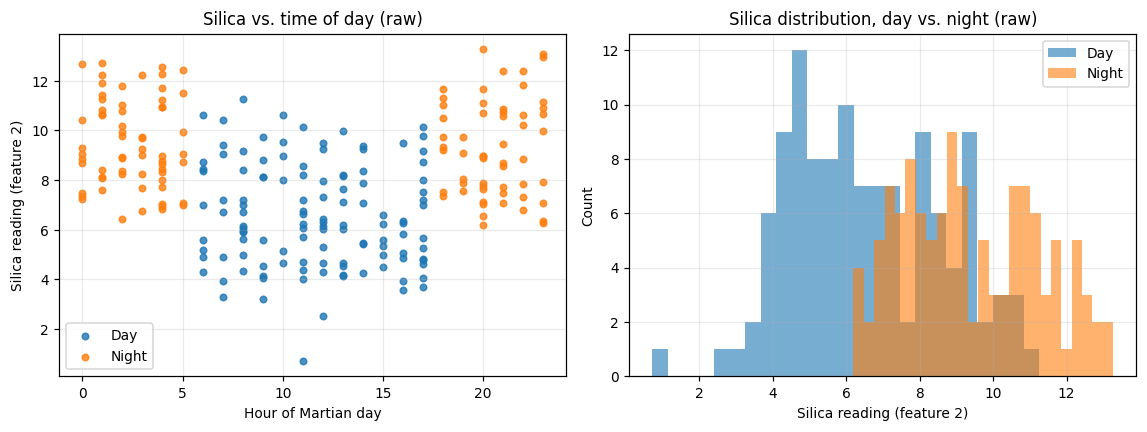

In [3]:
# =====================================================================
# PART 1, TASK 1: PROVIDED FOR YOU. Run this and study the plot.
# =====================================================================

night_mask = (timestamps >= 18) | (timestamps < 6)

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4))

axes[0].scatter(timestamps[~night_mask], raw_data[~night_mask, 2],
                s=18, label="Day", alpha=0.8)
axes[0].scatter(timestamps[night_mask], raw_data[night_mask, 2],
                s=18, label="Night", alpha=0.8)
axes[0].set(xlabel="Hour of Martian day", ylabel="Silica reading (feature 2)",
            title="Silica vs. time of day (raw)")
axes[0].legend()

axes[1].hist(raw_data[~night_mask, 2], bins=25, alpha=0.6, label="Day")
axes[1].hist(raw_data[night_mask, 2], bins=25, alpha=0.6, label="Night")
axes[1].set(xlabel="Silica reading (feature 2)", ylabel="Count",
            title="Silica distribution, day vs. night (raw)")
axes[1].legend()

plt.tight_layout(); plt.show()

Look at the left plot. Readings taken between 18:00 and 06:00 sit visibly higher
than daytime readings of the same feature. That vertical offset is the
instrument bias you must remove.

## Part 1, Task 2: Correct the systematic bias (5 points)

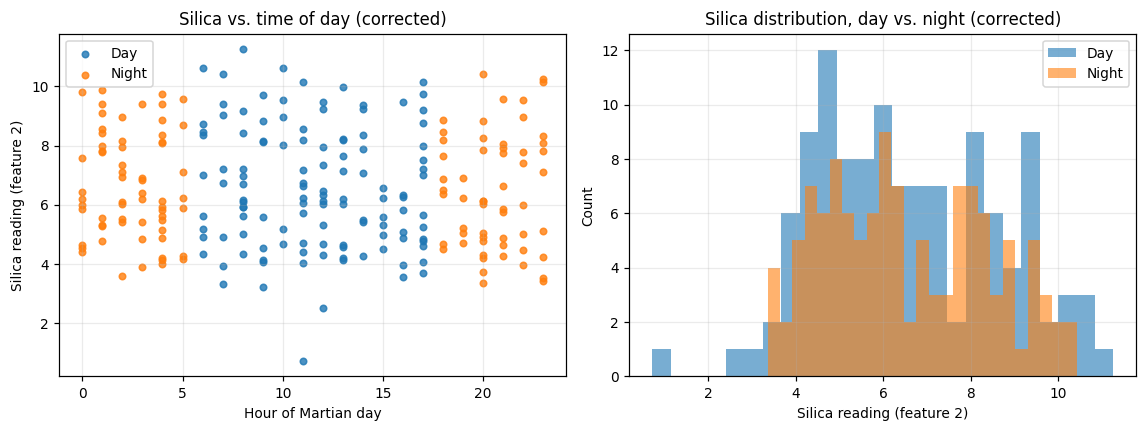

In [4]:
# =====================================================================
# YOUR CODE HERE (5 points)
#
# 1. Build a boolean mask for the nighttime readings (18:00-06:00).
# 2. Estimate the additive bias in feature 2 and subtract it from the
#    night readings only. Leave the other four features untouched.
#    Think about WHY a night-versus-day comparison is a valid way to
#    estimate the bias, and justify your choice of statistic.
# 3. Re-plot the two figures above using your corrected data to show
#    the time-of-day effect is gone.
#
# Store your result in a variable called corrected_data.
# =====================================================================

night_mask = (timestamps >= 18) | (timestamps < 6)

corrected_data = raw_data.copy()

bias_offset = raw_data[night_mask, 2].mean() - raw_data[~night_mask, 2].mean()
corrected_data[night_mask, 2] -= bias_offset

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4))

axes[0].scatter(timestamps[~night_mask], corrected_data[~night_mask, 2],
                s=18, label="Day", alpha=0.8)
axes[0].scatter(timestamps[night_mask], corrected_data[night_mask, 2],
                s=18, label="Night", alpha=0.8)
axes[0].set(xlabel="Hour of Martian day", ylabel="Silica reading (feature 2)",
            title="Silica vs. time of day (corrected)")
axes[0].legend()

axes[1].hist(corrected_data[~night_mask, 2], bins=25, alpha=0.6, label="Day")
axes[1].hist(corrected_data[night_mask, 2], bins=25, alpha=0.6, label="Night")
axes[1].set(xlabel="Silica reading (feature 2)", ylabel="Count",
            title="Silica distribution, day vs. night (corrected)")
axes[1].legend()

plt.tight_layout(); plt.show()

I estimated the additive bias using the difference of sample means: the nighttime mean silica reading minus the daytime mean. Because the three true rock-type clusters are assumed to be reasonably well mixed across day and night, their compositions should contribute similarly to both groups, so the difference in means predominantly reflects the instrument's nighttime offset. I subtracted this estimated offset from nighttime silica readings only.

## Part 2: The robust mixture model (25 points)

The density of a single reading under this model is

$$f(\mathbf{x}) = \underbrace{\pi_1 \mathcal{N}(\mathbf{x}; \bm{\mu}_1, \bm{\Sigma}_1) + \pi_2 \mathcal{N}(\mathbf{x}; \bm{\mu}_2, \bm{\Sigma}_2) + \pi_3 \mathcal{N}(\mathbf{x}; \bm{\mu}_3, \bm{\Sigma}_3)}_{\text{three rock types}} + \underbrace{\pi_4 u}_{\text{ChemCam misfires}}$$

where $u$ is a constant: the density of a uniform distribution over the
bounding box of the data. This is the law of total probability, with a
continuous observation instead of a discrete one.

In [5]:
class RobustMixtureModel:
    """Mixture of 3 Gaussians plus 1 uniform component for outliers.

    Component indices 0, 1, 2 are the rock types.
    Component index 3 is the uniform "garbage" component for misfires.
    """

    def __init__(self, n_gaussians=3, n_iter=100, random_state=8):
        self.n_gaussians = n_gaussians
        self.n_components = n_gaussians + 1      # +1 for the uniform component
        self.n_iter = n_iter
        self.random_state = random_state

    # -----------------------------------------------------------------
    # PROVIDED FOR YOU. DO NOT MODIFY.
    # -----------------------------------------------------------------
    def _initialize(self, X):
        """Set starting parameters.

        The initialisation is fixed so that everyone's results are
        comparable. EM only finds a local optimum, so a different
        starting point can give a noticeably different answer.
        """
        n_samples, n_features = X.shape
        rng = np.random.default_rng(self.random_state)

        # Each Gaussian starts centred on a randomly chosen data point,
        # as a unit-variance sphere.
        self.means = X[rng.choice(n_samples, self.n_gaussians,
                                  replace=False)].astype(float)
        self.covs = np.array([np.eye(n_features)
                              for _ in range(self.n_gaussians)])

        # All four components start equally likely.
        self.weights = np.ones(self.n_components) / self.n_components

        # The uniform component is spread over the bounding box of the data,
        # so its density is one over that volume: a constant.
        lo, hi = X.min(axis=0).min(), X.max(axis=0).max()
        self.uniform_density = 1.0 / (hi - lo) ** n_features

    # -----------------------------------------------------------------
    # PART 2, TASK 1: THE ASSIGNMENT STEP. PROVIDED FOR YOU.
    #
    # This is Bayes' theorem:
    #       gamma[i, k] = P(component k | x_i)
    #                   = pi_k * f_k(x_i) / sum_j pi_j * f_j(x_i)
    # Numerator is prior times likelihood. Denominator is the law of
    # total probability. Each row of the result sums to 1.
    # -----------------------------------------------------------------
    def _e_step(self, X):
        likelihoods = np.zeros((X.shape[0], self.n_components))

        # The three Gaussian components.
        for k in range(self.n_gaussians):
            dist = multivariate_normal(self.means[k], self.covs[k],
                                       allow_singular=True)
            likelihoods[:, k] = dist.pdf(X)

        # The uniform component: a constant density, no dependence on x.
        likelihoods[:, self.n_gaussians] = self.uniform_density

        numerator = likelihoods * self.weights
        denominator = numerator.sum(axis=1)[:, np.newaxis]
        return numerator / (denominator + 1e-300)

    # -----------------------------------------------------------------
    # PROVIDED FOR YOU. Used for the required diagnostic printout.
    # -----------------------------------------------------------------
    def log_likelihood(self, X):
        """Total log-likelihood. EM guarantees this never decreases."""
        likelihoods = np.zeros((X.shape[0], self.n_components))
        for k in range(self.n_gaussians):
            dist = multivariate_normal(self.means[k], self.covs[k],
                                       allow_singular=True)
            likelihoods[:, k] = dist.pdf(X)
        likelihoods[:, self.n_gaussians] = self.uniform_density
        total = (likelihoods * self.weights).sum(axis=1)
        return float(np.log(total + 1e-300).sum())


    # -----------------------------------------------------------------
    # PART 2, TASK 2: THE UPDATE STEP (15 points). YOUR CODE HERE.
    #
    # Given the responsibilities gamma from the assignment step, refit
    # every component using RESPONSIBILITY-WEIGHTED averages.
    #
    #   N_k    = sum_i gamma[i, k]                 (effective count)
    #   pi_k   = N_k / N                           for ALL FOUR components
    #   mu_k   = (1 / N_k) sum_i gamma[i,k] x_i    for the 3 Gaussians only
    #   Sigma_k= (1 / N_k) sum_i gamma[i,k]
    #                      (x_i - mu_k)(x_i - mu_k)^T    3 Gaussians only
    #
    # NOTE: the uniform component has NO mean and NO covariance.
    #       Only its weight self.weights[3] is updated.
    #       np.cov will NOT give you the weighted covariance above.
    #       Add 1e-6 * np.eye(n_features) to each covariance so it stays
    #       invertible.
    # -----------------------------------------------------------------
    def _m_step(self, X, responsibilities):
        n_samples, n_features = X.shape

        for k in range(self.n_gaussians):
            N_k = responsibilities[:, k].sum()
            self.means[k] = (responsibilities[:, k][:, None] * X).sum(axis=0) / N_k

            diff = X - self.means[k]
            self.covs[k] = (responsibilities[:, k][:, None, None] *
                            np.einsum('ni,nj->nij', diff, diff)).sum(axis=0) / N_k
            self.covs[k] += 1e-6 * np.eye(n_features)

        self.weights = responsibilities.sum(axis=0) / n_samples

    # -----------------------------------------------------------------
    # PART 2, TASK 3: THE TRAINING LOOP (10 points). YOUR CODE HERE.
    #
    # 1. Call self._initialize(X)  (provided above).
    # 2. Loop self.n_iter times, alternating the assignment step and the
    #    update step.
    # 3. At each iteration, record self.log_likelihood(X) in self.history
    #    and print it. It must never decrease.
    # -----------------------------------------------------------------
    def fit(self, X, verbose=True):
        self._initialize(X)
        self.history = []

        for i in range(self.n_iter):
            responsibilities = self._e_step(X)
            self._m_step(X, responsibilities)
            ll = self.log_likelihood(X)
            self.history.append(ll)
            if verbose:
                print(f"Iteration {i+1}/{self.n_iter}: log-likelihood = {ll:.4f}")

        return self

    # PROVIDED FOR YOU.
    def predict(self, X):
        """Hard label for each point: the most responsible component."""
        return np.argmax(self._e_step(X), axis=1)

### Train the model

In [6]:
model = RobustMixtureModel(n_gaussians=3, n_iter=100, random_state=8)
model.fit(corrected_data)
labels = model.predict(corrected_data)

print(f"\nMixing weights (3 rock types, then misfires): "
      f"{np.round(model.weights, 4)}")
for k in range(4):
    name = f"Rock type {k}" if k < 3 else "Misfires (outliers)"
    print(f"  Component {k} ({name}): {(labels == k).sum()} points")

Iteration 1/100: log-likelihood = -1536.4939
Iteration 2/100: log-likelihood = -1532.9035
Iteration 3/100: log-likelihood = -1529.7482
Iteration 4/100: log-likelihood = -1527.2334
Iteration 5/100: log-likelihood = -1525.2521
Iteration 6/100: log-likelihood = -1523.6478
Iteration 7/100: log-likelihood = -1522.4168
Iteration 8/100: log-likelihood = -1521.5294
Iteration 9/100: log-likelihood = -1520.8991
Iteration 10/100: log-likelihood = -1520.4330
Iteration 11/100: log-likelihood = -1520.0629
Iteration 12/100: log-likelihood = -1519.7276
Iteration 13/100: log-likelihood = -1519.3699
Iteration 14/100: log-likelihood = -1518.9506
Iteration 15/100: log-likelihood = -1518.4615
Iteration 16/100: log-likelihood = -1517.9192
Iteration 17/100: log-likelihood = -1517.3395
Iteration 18/100: log-likelihood = -1516.7375
Iteration 19/100: log-likelihood = -1516.1255
Iteration 20/100: log-likelihood = -1515.5010
Iteration 21/100: log-likelihood = -1514.8582
Iteration 22/100: log-likelihood = -1514.19

### The required diagnostic

EM guarantees the log-likelihood never decreases. Check that yours does not.
If it falls, oscillates, or prints `nan`, the update step is wrong.

Log-likelihood: -1536.49 -> -1486.12
Monotonically non-decreasing: True
Smallest step: 1.506e-05


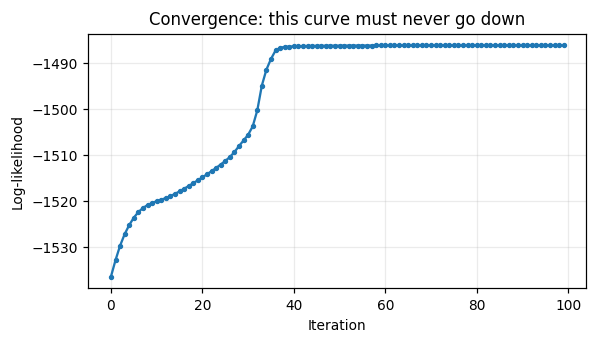

In [7]:
history = np.array(model.history)
steps = np.diff(history)
print(f"Log-likelihood: {history[0]:.2f} -> {history[-1]:.2f}")
print(f"Monotonically non-decreasing: {bool((steps >= -1e-6).all())}")
print(f"Smallest step: {steps.min():.3e}")

plt.figure(figsize=(5.5, 3.2))
plt.plot(history, "o-", ms=2.5)
plt.xlabel("Iteration"); plt.ylabel("Log-likelihood")
plt.title("Convergence: this curve must never go down")
plt.tight_layout(); plt.show()

## Part 3: Visualisation with PCA (5 points)

In [8]:
# =====================================================================
# YOUR CODE HERE (5 points)
#
# Task 1 (2 pts): apply PCA to corrected_data, reducing to 2 components.
# Task 2 (3 pts): scatter plot the 2D result, coloured by the labels from
#                 your model. Use three distinct colours for the rock
#                 types and a visually separate colour (grey or black)
#                 for the points labelled as misfires.
# =====================================================================

from sklearn.decomposition import PCA

# YOUR CODE HERE

## Part 4, Task 1: Standard clustering models (5 points)

In [9]:
# =====================================================================
# YOUR CODE HERE (5 points)
#
# 1. Train sklearn's GaussianMixture with 3 components on corrected_data.
# 2. Train sklearn's KMeans with 3 clusters on the same data.
# 3. Make two PCA scatter plots, one for each, in the same style as
#    Part 3 so they can be compared side by side with your own model.
# =====================================================================

from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

# YOUR CODE HERE

## Part 4, Task 2: Discussion (10 points)

**Write your answers here.**

1. Compare your model's PCA plot with the two plots from the standard models.
   How did KMeans and the standard GMM handle the outlier data points?

2. Discuss the advantages of explicitly modeling outliers with a dedicated
   "garbage" component.

3. What are some potential limitations of modeling outliers with a single
   uniform distribution? When might this assumption fail?

## Bonus: PCA from scratch (5 points)

In [10]:
# =====================================================================
# YOUR CODE HERE (5 bonus points)
#
# 1. Centre corrected_data by subtracting each feature's mean.
# 2. Compute the covariance matrix of the centred data.
# 3. Find its eigenvalues and eigenvectors (np.linalg.eigh).
# 4. Sort by eigenvalue and project onto the top two eigenvectors.
# 5. Scatter plot the result, coloured by your model's labels, and
#    compare it to your Part 3 plot.
# =====================================================================

# YOUR CODE HERE

**Write your comparison here.** Does your from-scratch plot look the same as
the library version from Part 3? If it differs, explain why.